In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Display first 6 rows of the data
print("First 7 rows of the dataset:")
df = pd.read_csv('/content/plant_disease_dataset.csv')

First 7 rows of the dataset:


In [ ]:
df.head()

,temperature,humidity,rainfall,soil_pH,disease_present
0,27.483571,33.215053,0.572758,4.975875,1
1,24.308678,36.945005,42.522346,8.165266,0
2,28.238443,34.026189,16.095303,6.316734,1
3,32.615149,41.104180,20.311015,6.164949,0
4,23.829233,51.971785,11.851323,8.482468,0


**Check dataset information**

In [ ]:
print(df.shape)
print(df.columns)

(10000, 5)
Index(['temperature', 'humidity', 'rainfall', 'soil_pH', 'disease_present'], dtype='object')


**Missing Value Analysis**

In [ ]:
# Check for missing values in the dataset
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
temperature        0
humidity           0
rainfall           0
soil_pH            0
disease_present    0
dtype: int64


In [ ]:
# The total number of missing values
print("Total missing values:"),
print(df.isnull().sum().sum())

Total missing values:
0


**Check Duplicate Records**

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


**Remove rows with missing target**

In [ ]:
df = df.dropna(subset=["disease_present"])

In [ ]:
#Import the required function
from scipy.stats import zscore

**Calculate Z-scores**

In [ ]:
z_scores = np.abs(
    zscore(df[numeric_columns])
)

**Outlier Detection**

In [ ]:
outlier_mask = (
    z_scores > 3
).any(axis=1)

In [ ]:
#Count the outliers
print(
    "Number of outlier rows:",
    outlier_mask.sum()
)

Number of outlier rows: 301


In [ ]:
#Remove the outliers
df_clean = df[
    ~outlier_mask
].copy()

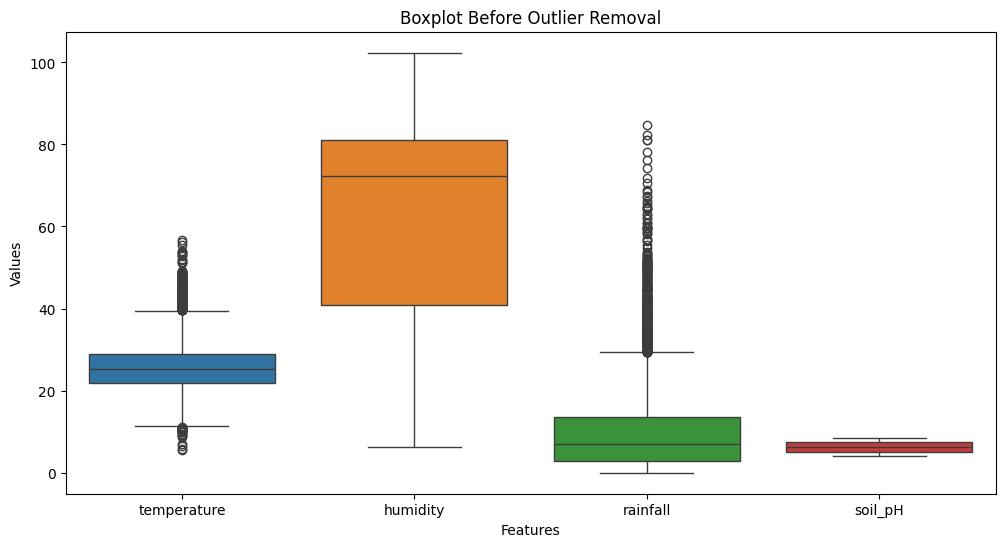

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[numeric_columns]
)

plt.title("Boxplot Before Outlier Removal")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

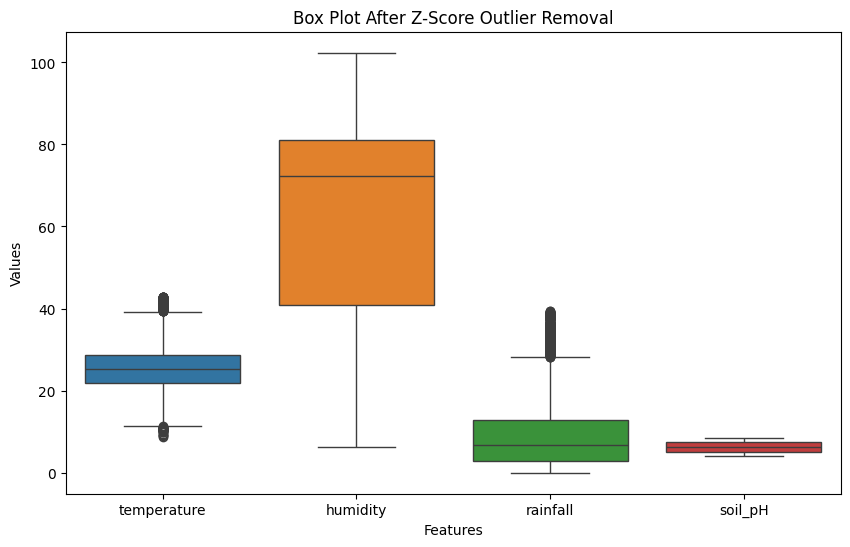

In [ ]:
#After removal
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_clean[numeric_columns])

plt.title("Box Plot After Z-Score Outlier Removal")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [ ]:
#Compare before and after
print(
    "Rows before outlier removal:",
    len(df)
)

print(
    "Rows after outlier removal:",
    len(df_clean)
)

print(
    "Rows removed:",
    len(df) - len(df_clean)
)

Rows before outlier removal: 10000
Rows after outlier removal: 9699
Rows removed: 301
